# HW1 Task 2 — Audio Filters for TIMIT

**Authors:** Roman Pavlosiuk, Iryna Denysova

We apply classical signal-processing filters (no deep learning) to TIMIT audio and measure
whether they improve phoneme recognition PER. Each filter is defined, visualised, and then
tested in an ablation study.

## 1. Setup

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import gc
import re
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import signal as scipy_signal
from transformers import AutoFeatureExtractor, HubertModel
from transformers import logging as hf_logging
from tqdm import tqdm

try:
    import editdistance as _ed
    def edit_distance(a, b): return _ed.eval(a, b)
except ImportError:
    def edit_distance(a, b):
        m, n = len(a), len(b)
        dp = list(range(n + 1))
        for i in range(1, m + 1):
            prev, dp[0] = dp[0], i
            for j in range(1, n + 1):
                prev, dp[j] = dp[j], prev if a[i-1]==b[j-1] else 1+min(prev, dp[j], dp[j-1])
        return dp[n]

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

In [ ]:
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
SAMPLE_RATE = 16_000
CNN_STRIDE  = 320
DATA_DIR    = './archive/data'
TRAIN_CSV   = './archive/train_data.csv'
TEST_CSV    = './archive/test_data.csv'
CHECKPOINT_DIR = './checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Set the device (GPU or CPU), audio settings, data paths, and create the folder for saving model checkpoints.

In [5]:
FOLD_MAP = {
    'ao':'aa','ax':'ah','ax-h':'ah','axr':'er','hv':'hh','ix':'ih',
    'el':'l','em':'m','en':'n','nx':'n','eng':'ng','zh':'sh','ux':'uw',
    'pcl':'sil','tcl':'sil','kcl':'sil','bcl':'sil','dcl':'sil','gcl':'sil',
    'h#':'sil','pau':'sil','epi':'sil','q':None,
}
PHONEMES_39 = [
    'aa','ae','ah','aw','ay','b','ch','d','dh','dx',
    'eh','er','ey','f','g','hh','ih','iy','jh','k',
    'l','m','n','ng','ow','oy','p','r','s','sh',
    'sil','t','th','uh','uw','v','w','y','z',
]
PHONE2IDX = {p: i for i, p in enumerate(PHONEMES_39)}
IDX2PHONE = {i: p for i, p in enumerate(PHONEMES_39)}
NUM_PHONEMES = len(PHONEMES_39)
    

This code folds many detailed phones in a standard set of 39 phonemes, then builds mappings between phoneme symbols and their numeric indices, plus the total phoneme count.

In [6]:
def normalize_phone(phone):
    return FOLD_MAP.get(phone.lower(), phone.lower())

def load_audio(wav_path):
    audio, sr = sf.read(wav_path)
    if audio.ndim > 1: audio = audio.mean(axis=1)
    assert sr == SAMPLE_RATE
    return audio.astype(np.float32)

def read_phn_file(phn_path):
    segments = []
    with open(phn_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3: continue
            phone = normalize_phone(parts[2])
            if phone is not None:
                segments.append((int(parts[0]), int(parts[1]),
                                  PHONE2IDX.get(phone, PHONE2IDX['sil'])))
    return segments

def segments_to_frame_labels(segments, num_frames, stride=CNN_STRIDE):
    labels = np.full(num_frames, PHONE2IDX['sil'], dtype=np.int64)
    for t in range(num_frames):
        centre = t * stride + stride // 2
        for start, end, idx in segments:
            if start <= centre < end:
                labels[t] = idx
                break
    return labels

def get_reference_phones(phn_path):
    return [IDX2PHONE[idx] for _, _, idx in read_phn_file(phn_path)
            if IDX2PHONE[idx] != 'sil']

def get_file_pairs(csv_path, data_dir, exclude_sa=True):
    df   = pd.read_csv(csv_path)
    rows = df[df['is_converted_audio'].astype(str).str.upper() == 'TRUE']
    pairs = []
    for _, row in rows.iterrows():
        wav_rel  = row['path_from_data_dir']
        fname    = os.path.basename(wav_rel)
        if exclude_sa and re.match(r'SA\d+', fname, re.IGNORECASE): continue
        wav_full = os.path.join(data_dir, wav_rel)
        phn_full = os.path.join(data_dir, re.sub(r'\.WAV\.wav$', '.PHN',
                                                   wav_rel, flags=re.IGNORECASE))
        if os.path.isfile(wav_full) and os.path.isfile(phn_full):
            pairs.append((wav_full, phn_full))
    return pairs

train_pairs = get_file_pairs(TRAIN_CSV, DATA_DIR)
test_pairs  = get_file_pairs(TEST_CSV,  DATA_DIR)
print(f'train: {len(train_pairs)}  test: {len(test_pairs)}')

train: 3696  test: 1344


- *normalize_phone* makes the phone lowercase and replaces it using FOLD_MAP if possible. 
- *load_audio* reads a WAV file, makes it mono if needed, checks the sample rate, and returns float32 audio. 
- *read_phn_file* reads a .PHN file, normalizes phones, ignores invalid ones, and returns a list of segments with their start, end, and phoneme index. 
- *segments_to_frame_labels* converts these time segments into frame-level phoneme labels for each CNN frame using the stride. 
- *get_reference_phones* loads phones from a .PHN file and returns the sequence of non‑silence phoneme symbols
- *get_file_pairs* reads the CSV, finds matching WAV and PHN files for converted audio (optionally skipping SA files), and returns a list of valid path pairs. 

At the end, the code builds train and test pairs and prints how many examples are in each set.

## 2. Filters

In [7]:
sample_wav, sample_phn = train_pairs[0]
raw = load_audio(sample_wav)
print(f'Sample: {os.path.basename(sample_wav)}  ({len(raw)/SAMPLE_RATE:.2f} s)')

Sample: SI681.WAV.wav  (2.50 s)


This code takes the first training WAV file, loads it, and prints its name and duration in seconds; later it will be used as a demo example to show how the filters work.

In [8]:
def plot_filter_effect(raw, filtered, title):
    """Show waveform and spectrogram before/after a filter, plus SNR."""
    noise        = filtered - raw
    power_signal = np.mean(raw ** 2)
    power_noise  = np.mean(noise ** 2)
    db = 10 * np.log10(power_signal / (power_noise + 1e-12))

    t   = np.arange(len(raw)) / SAMPLE_RATE
    fig, axes = plt.subplots(2, 2, figsize=(14, 5))
    fig.suptitle(f'{title}  |  SNR {db:.1f} dB', fontsize=12)

    axes[0, 0].plot(t, raw,      lw=0.4, color='steelblue')
    axes[0, 0].set_title('Waveform — original'); axes[0, 0].set_xlabel('Time (s)')
    axes[0, 1].plot(t, filtered, lw=0.4, color='coral')
    axes[0, 1].set_title('Waveform — filtered'); axes[0, 1].set_xlabel('Time (s)')

    for ax, audio, label in [(axes[1, 0], raw, 'original'),
                              (axes[1, 1], filtered, 'filtered')]:
        f, ts, Sxx = scipy_signal.spectrogram(audio, fs=SAMPLE_RATE, nperseg=512)
        ax.pcolormesh(ts, f / 1000, 10 * np.log10(Sxx + 1e-10),
                      shading='gouraud', cmap='magma')
        ax.set_ylabel('Freq (kHz)'); ax.set_xlabel('Time (s)')
        ax.set_title(f'Spectrogram — {label}')

    fig.tight_layout()
    plt.show()

### Pre-emphasis

`y[t] = x[t] - 0.97 * x[t-1]`

Subtracts a scaled version of the previous sample from the current one. This boosts high frequencies and compensates for the natural energy roll-off of the vocal tract. Makes consonants like `s`, `sh`, `f` more prominent in the spectrogram.

In [9]:
def pre_emphasis(audio: np.ndarray, coef: float = 0.97) -> np.ndarray:
    return np.concatenate([[audio[0]], audio[1:] - coef * audio[:-1]]).astype(np.float32)

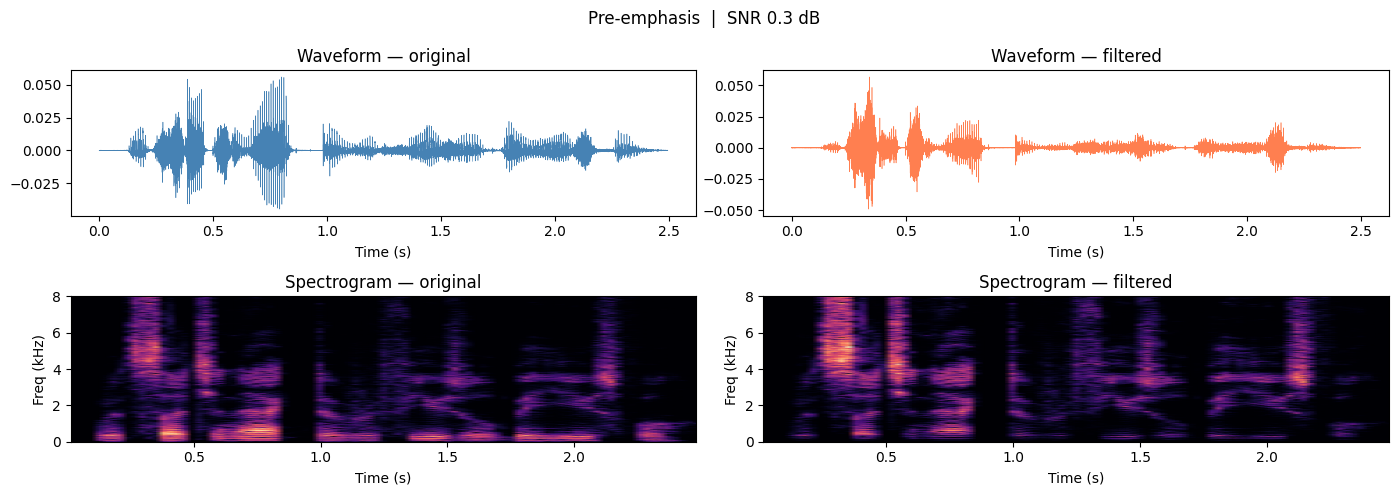

In [10]:
plot_filter_effect(raw, pre_emphasis(raw), 'Pre-emphasis')

### Bandpass Filter

Keeps only frequencies between 80 Hz and 7600 Hz using a 5th-order Butterworth filter. Speech sits in roughly 80–8000 Hz. Cutting below 80 Hz removes DC offset and microphone rumble; cutting above 7600 Hz removes high-frequency hiss near the Nyquist limit.

In [11]:
def bandpass_filter(audio: np.ndarray, low: float = 80.0, high: float = 7600.0,
                    sr: int = 16000, order: int = 5) -> np.ndarray:
    nyq  = sr / 2
    b, a = scipy_signal.butter(order, [low / nyq, high / nyq], btype='band')
    return scipy_signal.filtfilt(b, a, audio).astype(np.float32)

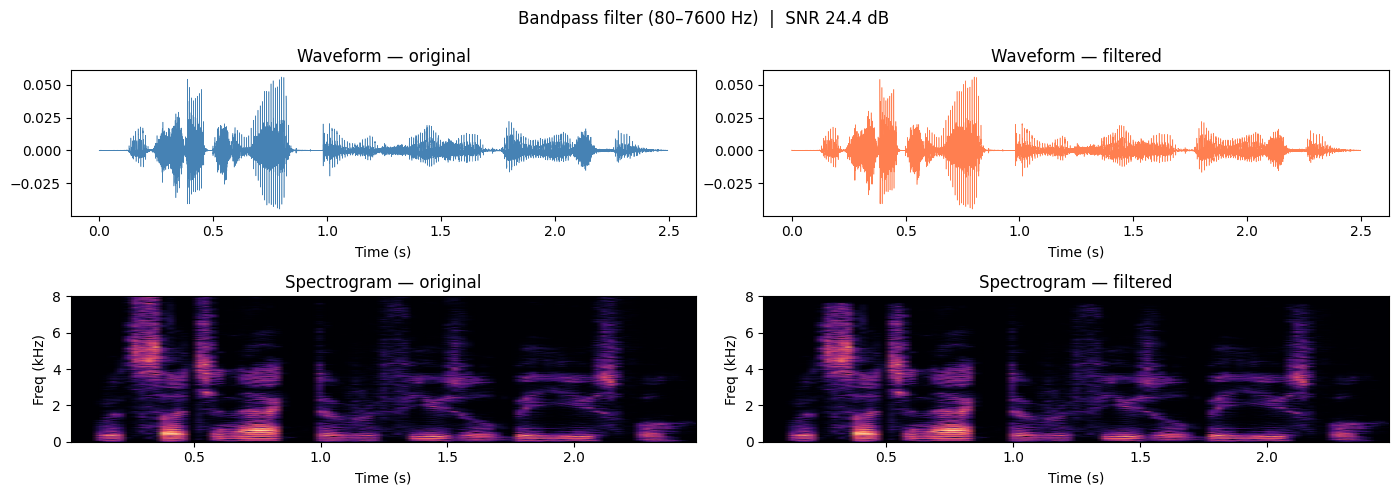

In [12]:
plot_filter_effect(raw, bandpass_filter(raw), 'Bandpass filter (80–7600 Hz)')

### RMS Normalization

Scales the audio so all utterances have the same RMS energy level. Some TIMIT speakers are louder than others — this makes the input amplitude consistent across the dataset.

In [13]:
def rms_normalize(audio: np.ndarray, target_rms: float = 0.05) -> np.ndarray:
    rms = np.sqrt(np.mean(audio ** 2))
    if rms > 1e-8:
        audio = audio * (target_rms / rms)
    return np.clip(audio, -1.0, 1.0).astype(np.float32)

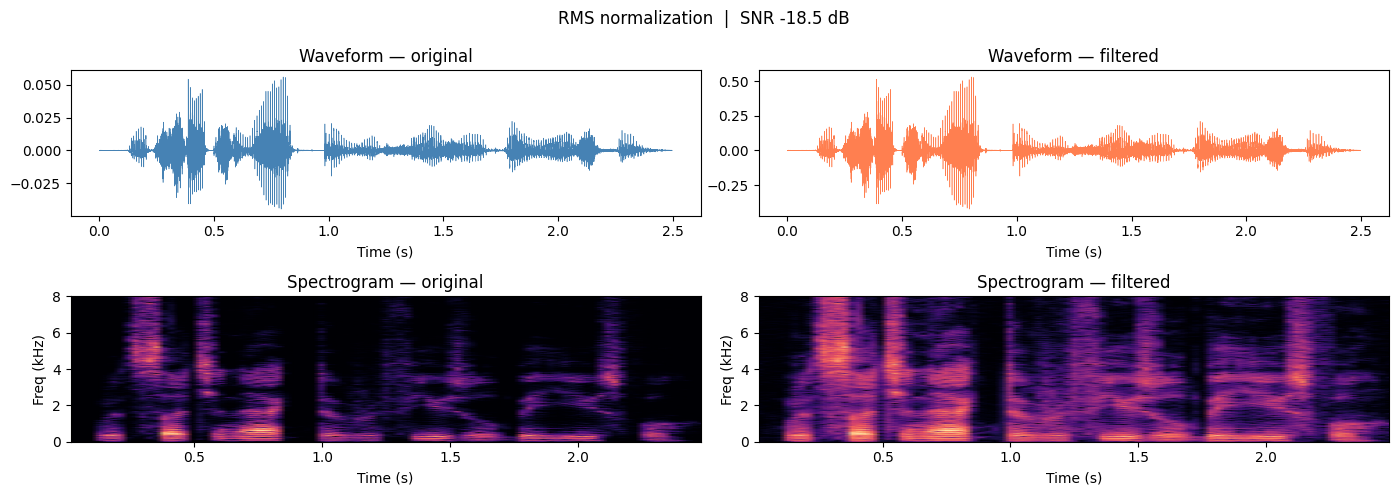

In [14]:
plot_filter_effect(raw, rms_normalize(raw), 'RMS normalization')

### Noise Gate

Splits the audio into 20 ms frames (same size as CNN_STRIDE) and zeros out any frame whose RMS energy falls below –40 dB. Removes background hiss and breath noise during silent parts without touching active speech frames.

In [15]:
def noise_gate(audio: np.ndarray, threshold_db: float = -40.0,
               frame_len: int = 320) -> np.ndarray:
    threshold = 10 ** (threshold_db / 20)
    out = audio.copy()
    for i in range(0, len(audio), frame_len):
        frame = audio[i:i + frame_len]
        if np.sqrt(np.mean(frame ** 2)) < threshold:
            out[i:i + frame_len] = 0.0
    return out.astype(np.float32)

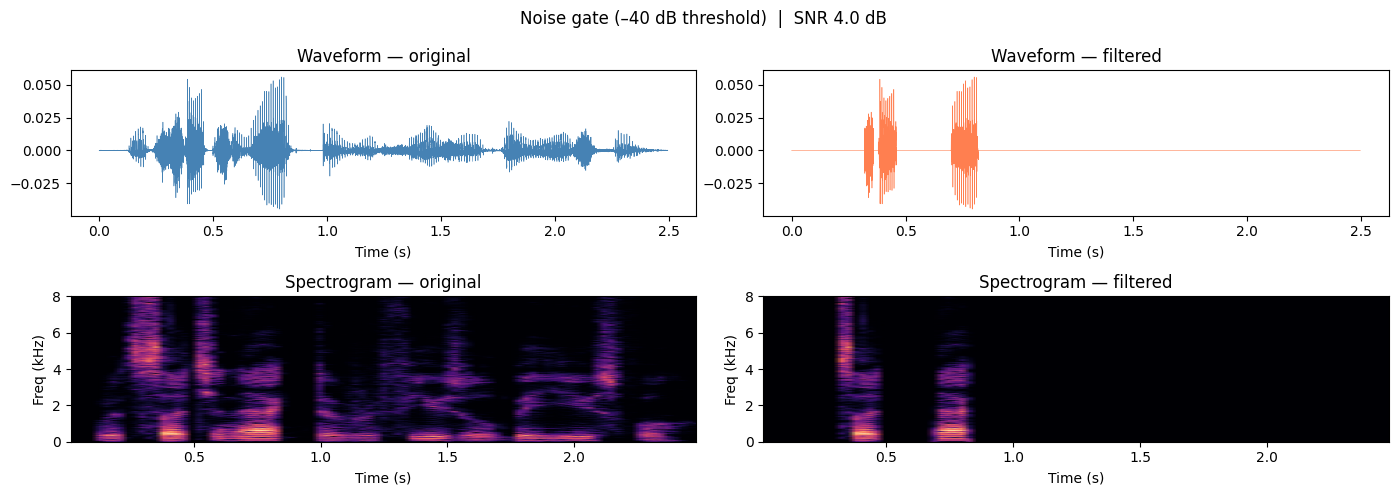

In [16]:
plot_filter_effect(raw, noise_gate(raw), 'Noise gate (–40 dB threshold)')

### Spectral Subtraction

Classic noise reduction algorithm from signal processing:
1. Compute the STFT (short-time Fourier transform) of the signal
2. Assume the first 10 frames are background noise
3. Estimate the noise spectrum from those frames
4. Subtract it from all frames
5. Reconstruct via inverse STFT

Phase is left unchanged — only the magnitude spectrum is modified.

In [17]:
def spectral_subtraction(audio: np.ndarray, sr: int = 16000, frame_len: int = 512,
                         hop: int = 256, noise_frames: int = 10,
                         alpha: float = 2.0) -> np.ndarray:
    _, _, Zxx  = scipy_signal.stft(audio, fs=sr, nperseg=frame_len,
                                    noverlap=frame_len - hop)
    mag        = np.abs(Zxx)
    phase      = np.angle(Zxx)
    noise_est  = np.mean(mag[:, :noise_frames], axis=1, keepdims=True)
    mag_clean  = np.maximum(mag - alpha * noise_est, 0.0)
    _, out     = scipy_signal.istft(mag_clean * np.exp(1j * phase), fs=sr,
                                     nperseg=frame_len, noverlap=frame_len - hop)
    out = out[:len(audio)]
    if len(out) < len(audio):
        out = np.pad(out, (0, len(audio) - len(out)))
    return out.astype(np.float32)

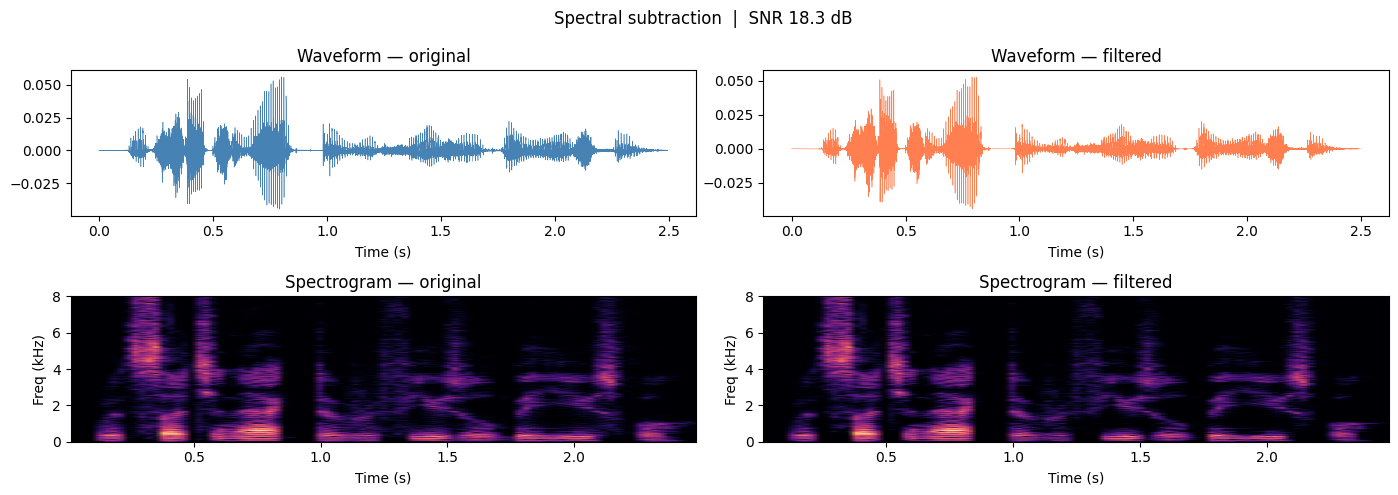

In [18]:
plot_filter_effect(raw, spectral_subtraction(raw), 'Spectral subtraction')

## 3. Ablation Study

We train HuBERT-base + MLP (same setup as Task 1, layer 12) with each filter applied during feature extraction. Baseline = no filter.

In [19]:
class MLPProbe(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=512,
                 num_classes=NUM_PHONEMES, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, x): return self.net(x)

The class defines a small neural network that takes frame features as input and predicts a phoneme class for each frame.

In [20]:
def build_loader(feats_list, labels_list, batch_size=2048, shuffle=True):
    X = torch.from_numpy(np.concatenate(feats_list,  axis=0))
    y = torch.from_numpy(np.concatenate(labels_list, axis=0))
    return DataLoader(TensorDataset(X, y), batch_size=batch_size,
                      shuffle=shuffle, num_workers=0)

This function stacks all feature and label arrays into tensors and creates a DataLoader that yields mini‑batches for training.

In [21]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = total_correct = total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * len(y)
        total_correct += (logits.argmax(-1) == y).sum().item()
        total         += len(y)
    return total_loss / total, total_correct / total

Here we train the model for one epoch on these batches and returns the average loss and accuracy over the epoch.

In [22]:
def compute_per(model, feats_list, refs_list, device):
    model.eval()
    total_dist = total_len = 0
    with torch.no_grad():
        for feats, ref in zip(feats_list, refs_list):
            logits = model(torch.from_numpy(feats).to(device))
            preds  = logits.argmax(-1).cpu().numpy()
            hyp, prev = [], -1
            for p in preds:
                if p != prev:
                    ph = IDX2PHONE[p]
                    if ph != 'sil': hyp.append(ph)
                    prev = p
            if ref:
                total_dist += edit_distance(hyp, ref)
                total_len  += len(ref)
    return total_dist / max(total_len, 1)

Function here runs the model on test features, converts frame predictions to phone sequences, and computes the phoneme error rate using edit distance.

In [23]:
def extract_features(file_pairs, processor, ssl_model, device,
                     desc='Extracting', filter_fn=None):
    ssl_model.eval()
    feats_list, labels_list, refs_list = [], [], []
    with torch.no_grad():
        for wav_path, phn_path in tqdm(file_pairs, desc=desc, leave=False):
            audio  = load_audio(wav_path)
            if filter_fn is not None:
                audio = filter_fn(audio)
            inputs = processor(audio, sampling_rate=SAMPLE_RATE,
                               return_tensors='pt').input_values.to(device)
            out    = ssl_model(inputs, output_hidden_states=False)
            feats  = out.last_hidden_state.squeeze(0).cpu().float().numpy()
            segs   = read_phn_file(phn_path)
            feats_list.append(feats)
            labels_list.append(segments_to_frame_labels(segs, feats.shape[0]))
            refs_list.append(get_reference_phones(phn_path))
    return feats_list, labels_list, refs_list

This function applies an optional filter to each audio file, runs HuBERT to get features, builds frame labels from phoneme segments, and collects reference phone sequences.

In [24]:
def _ckpt_path(name):
    return os.path.join(CHECKPOINT_DIR, re.sub(r'[^\w\-]', '_', name) + '.pt')

def run_filter_experiment(filter_name, filter_fn, train_pairs, test_pairs,
                          device, epochs=15):
    ckpt = _ckpt_path(f'filter_{filter_name}')
    if os.path.isfile(ckpt):
        data = torch.load(ckpt, map_location='cpu', weights_only=False)
        print(f'{filter_name:<24}  (checkpoint)  PER {data["per"]*100:.2f}%')
        return data['per']

    print(f'\n{filter_name}')
    processor = AutoFeatureExtractor.from_pretrained('facebook/hubert-base-ls960')
    ssl       = HubertModel.from_pretrained('facebook/hubert-base-ls960').to(device)
    ssl.requires_grad_(False)
    input_dim = ssl.config.hidden_size

    tr_f, tr_l, tr_r = extract_features(train_pairs, processor, ssl, device,
                                         desc='  train', filter_fn=filter_fn)
    te_f, te_l, te_r = extract_features(test_pairs,  processor, ssl, device,
                                         desc='  test',  filter_fn=filter_fn)
    del ssl, processor
    torch.cuda.empty_cache(); gc.collect()

    loader    = build_loader(tr_f, tr_l)
    model     = MLPProbe(input_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(1, epochs + 1):
        loss, acc = train_epoch(model, loader, optimizer, criterion, device)
        scheduler.step()
        if epoch == 1 or epoch % 5 == 0:
            print(f'  epoch {epoch:2d}/{epochs}  loss {loss:.4f}  acc {acc:.4f}')

    per = compute_per(model, te_f, te_r, device)
    print(f'  PER: {per*100:.2f}%')
    torch.save({'per': per}, ckpt)
    return per

Here the function _ckpt_path builds a safe checkpoint file path in the checkpoints folder for a given experiment name. 

Function run_filter_experiment runs the whole probe experiment for one filter: it extracts features, trains the MLP probe, evaluates PER on the test set, prints the result, and saves it to a checkpoint.

In [25]:
FILTER_CONFIGS = {
    'baseline':             None,
    'pre_emphasis':         pre_emphasis,
    'bandpass':             bandpass_filter,
    'rms_normalize':        rms_normalize,
    'noise_gate':           noise_gate,
    'spectral_subtraction': spectral_subtraction,
}

ablation_results = {}
for name, fn in FILTER_CONFIGS.items():
    ablation_results[name] = run_filter_experiment(
        name, fn, train_pairs, test_pairs, DEVICE
    )


baseline


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch  1/15  loss 0.5736  acc 0.8250
  epoch  5/15  loss 0.3200  acc 0.8852
  epoch 10/15  loss 0.2575  acc 0.9051
  epoch 15/15  loss 0.2260  acc 0.9167
  PER: 15.28%

pre_emphasis


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch  1/15  loss 0.5744  acc 0.8250
  epoch  5/15  loss 0.3232  acc 0.8845
  epoch 10/15  loss 0.2601  acc 0.9041
  epoch 15/15  loss 0.2290  acc 0.9156
  PER: 15.28%

bandpass


...

  epoch  1/15  loss 0.5690  acc 0.8258
  epoch  5/15  loss 0.3205  acc 0.8852
  epoch 10/15  loss 0.2583  acc 0.9049
  epoch 15/15  loss 0.2263  acc 0.9164
  PER: 15.34%

noise_gate


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch  1/15  loss 1.5719  acc 0.5637
  epoch  5/15  loss 1.2805  acc 0.6249
  epoch 10/15  loss 1.1762  acc 0.6490
  epoch 15/15  loss 1.1182  acc 0.6639
  PER: 54.95%

spectral_subtraction


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  epoch  1/15  loss 0.5820  acc 0.8232
  epoch  5/15  loss 0.3240  acc 0.8845
  epoch 10/15  loss 0.2606  acc 0.9044
  epoch 15/15  loss 0.2290  acc 0.9159
  PER: 15.62%


The code with FILTER_CONFIGS, the loop, and ablation_results runs run_filter_experiment for each filter configuration and stores the PER result so we can compare how each filter affects phoneme recognition. The results will be described in next sections.

## 4. Results

In [26]:
baseline = ablation_results['baseline']
print(f"{'Filter':<24}  {'PER':>8}  {'vs baseline':>12}")
print('-' * 50)
for name, per in ablation_results.items():
    delta = '—' if name == 'baseline' else f'{(per - baseline)*100:+.2f}%'
    print(f'{name:<24}  {per*100:>7.2f}%  {delta:>12}')

Filter                         PER   vs baseline
--------------------------------------------------
baseline                    15.28%             —
pre_emphasis                15.28%        -0.00%
bandpass                    15.21%        -0.07%
rms_normalize               15.34%        +0.06%
noise_gate                  54.95%       +39.67%
spectral_subtraction        15.62%        +0.34%


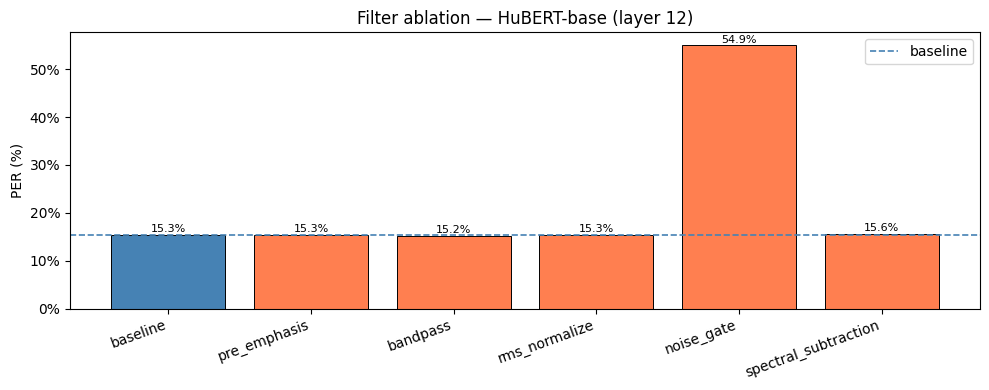

In [27]:
names  = list(ablation_results.keys())
pers   = [ablation_results[n] * 100 for n in names]
colors = ['steelblue' if n == 'baseline' else 'coral' for n in names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(names)), pers, color=colors, edgecolor='k', linewidth=0.7)
ax.axhline(baseline * 100, color='steelblue', linestyle='--', linewidth=1.2, label='baseline')
for bar, v in zip(bars, pers):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('PER (%)')
ax.set_title('Filter ablation — HuBERT-base (layer 12)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend()
fig.tight_layout()
plt.savefig('filter_ablation.png', dpi=120)
plt.show()

## Conclusions

Most filters didn't really help. Pre-emphasis, bandpass, rms_normalize and spectral subtraction all got basically the same PER as the baseline (~15.3%). The reason is simple — TIMIT is already a very clean dataset recorded in a studio, so there's no noise to remove. When you apply noise-removal filters to clean audio, you're not fixing anything, you're just slightly changing a signal that was already fine.

Bandpass gave a tiny improvement (15.21% vs 15.28%). It just cuts frequencies below 80 Hz which have nothing to do with speech anyway, so removing them didn't hurt and helped just a little.

Pre-emphasis did absolutely nothing (15.28% = same as baseline). This makes sense because HuBERT already has a CNN inside it that learns its own frequency adjustments during training. So applying pre-emphasis manually before the model is kind of doing the same thing twice.

Noise gate completely broke everything — PER jumped to 54.95%. The threshold we set (-40 dB) was too aggressive, so it didn't just silence background noise, it also zeroed out quiet parts of actual speech. HuBERT was never trained on audio with random chunks of silence in the middle of words, so it had no idea what to do with that.

Spectral subtraction made things slightly worse (15.62%). It tries to estimate background noise from the first few frames and subtract it, but since the audio is already clean, it ends up subtracting too much and creating weird artifacts instead.

Overall, the experiment shows that audio filters are useful when the data is actually noisy. For a clean dataset like TIMIT, they don't help and can even hurt. If we really wanted to improve the model, we'd probably get better results by adding synthetic noise to the training data rather than trying to clean it.